In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import time
import wave
from preprocessing import normalize_audio, whisper_tokinze, build_input

import numpy as np
import matplotlib.pyplot as plt
import torch

from transformers import (
    WhisperFeatureExtractor,
    WhisperForConditionalGeneration,
    WhisperProcessor,
 )

import webrtcvad

processor = WhisperProcessor.from_pretrained(
	"./models/whisper-large-v3-turbo"
 )

fe = WhisperFeatureExtractor.from_pretrained(
	"./models/whisper-large-v3-turbo"
 )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dtype = torch.float16 if device.type == "cuda" else torch.float32

triton_model = WhisperForConditionalGeneration.from_pretrained(
    "./models/whisper-large-v3-turbo",
    torch_dtype=model_dtype,
 )
triton_model.generation_config.forced_decoder_ids = None
triton_model.generation_config.suppress_tokens = None
triton_model.generation_config.begin_suppress_tokens = None
triton_model.generation_config.max_new_tokens = None
triton_model.generation_config.max_length = 96
triton_model = triton_model.to(device)
triton_model.eval()

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    print(f"Running Whisper on GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available, running Whisper on CPU")

vad = webrtcvad.Vad(2)

c:\Users\salee\Desktop\SomeIDFwew\triton\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 587/587 [00:01<00:00, 393.76it/s]


Running Whisper on GPU: NVIDIA GeForce RTX 2060


In [4]:
# /audio_20260513_174839.wav
AUDIO_DIR = 'saved_audio'
# TEST_AUDIO_PATH = list(map(lambda x: f"{AUDIO_DIR}/{x}", os.listdir(AUDIO_DIR)))

# https://www.youtube.com/live/fMwSH3n3N3A?si=CJcHmdDRtsnEkY2t
# https://www.cutyt.com/
TEST_AUDIO_PATH = ['saved_audio/bnm-1-ys.wav']


print(TEST_AUDIO_PATH)
WINDOW_SIZE = int(16000 * 2)

PCM_DTYPE_BY_WIDTH = {
    1: np.int8,
    2: np.int16,
    4: np.int32,
}

def stream_audio_chunks(wav_data, chunk_size=4096):
    for i in range(0, len(wav_data), chunk_size):
        yield wav_data[i:i+chunk_size]

def read_audio(audio_path: str):
    with wave.open(audio_path, "rb") as wav_file:
        sample_rate = wav_file.getframerate()
        channels = wav_file.getnchannels()
        sample_width = wav_file.getsampwidth()
        n_frames = wav_file.getnframes()

        print(f"Audio file info: sample_rate={sample_rate}, channels={channels}, sample_width={sample_width}, n_frames={n_frames}")
        wav_data = wav_file.readframes(n_frames)
        print(f"Read {len(wav_data)} bytes of audio data from {audio_path}")

        if sample_width not in PCM_DTYPE_BY_WIDTH:
            raise ValueError(f"Unsupported sample width: {sample_width}")

        # Convert raw PCM bytes to float32 in [-1, 1] for safe processing.
        pcm_dtype = PCM_DTYPE_BY_WIDTH[sample_width]
        raw_audio = np.frombuffer(wav_data, dtype=pcm_dtype)
        if channels > 1:
            raw_audio = raw_audio.reshape(-1, channels).mean(axis=1)
            channels = 1

        raw_audio = raw_audio[int(sample_rate * 60 * 8):int(sample_rate * 60 * 8.5)]

        info = np.iinfo(pcm_dtype)
        abs_max = float(max(info.max, abs(info.min)))
        audio = raw_audio.astype(np.float32) / abs_max

        if sample_rate != 16_000:
            print("Resampling audio to 16kHz")
            old_indices = np.arange(audio.shape[0], dtype=np.float32)
            new_length = int(round(audio.shape[0] * 16_000 / sample_rate))
            new_indices = np.linspace(0, audio.shape[0] - 1, new_length, dtype=np.float32)
            audio = np.interp(new_indices, old_indices, audio).astype(np.float32)
            sample_rate = 16_000

        # Re-encode as int16 PCM so downstream frombuffer-based normalization still works.
        wav_data = np.clip(audio * 32768.0, -32768, 32767).astype(np.int16).tobytes()
        sample_width = 2

    return { 'data': wav_data, 'sr': sample_rate, 'ch': channels, 'sw': sample_width }

['saved_audio/bnm-1-ys.wav']


In [5]:
data, sr, ch, sw = read_audio(TEST_AUDIO_PATH[0]).values()

Audio file info: sample_rate=44100, channels=2, sample_width=2, n_frames=100110336
Read 400441344 bytes of audio data from saved_audio/bnm-1-ys.wav
Resampling audio to 16kHz


In [6]:
TEN_MS = 10 / 1000
def vad_collector(chunk: bytes, bytes_per_ten_ms: int, vad: webrtcvad.Vad, sample_rate: int = 16000):
	frame_samples = int(TEN_MS * sample_rate)
	ret = []

	for frame_idx in range(0, len(chunk), bytes_per_ten_ms):
		frame = chunk[frame_idx:min(frame_idx + bytes_per_ten_ms, len(chunk))]
		frame = frame + b'\x00' * (bytes_per_ten_ms - len(frame))

		# each approval is for 10ms frame, i.e., sample_rate x 10ms samples.
		frame_approval = vad.is_speech(frame, 16000)
		ret.extend([frame_approval] * frame_samples)
	return np.array(ret, dtype=np.float32)

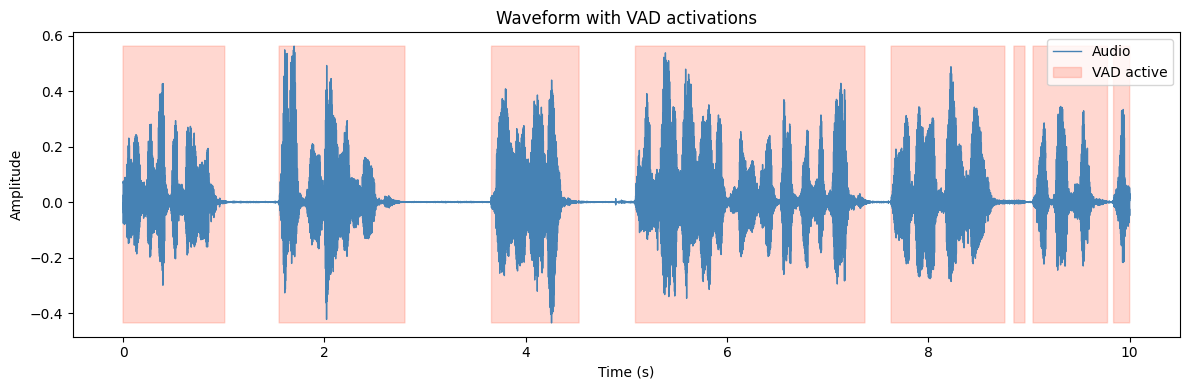

chunk duration: 10.000s


In [7]:
chunk_size = int(10 * 32_000) # 10s chunk
ten_ms = 10 / 1000
bytes_per_ten_ms = int(ten_ms * (sr * ch * sw))
frame_samples = int(ten_ms * sr)

for i in range(0, len(data), chunk_size):
	chunk = data[i:i + chunk_size]
	audio = normalize_audio(chunk)

	vad_mask = vad_collector(chunk, bytes_per_ten_ms, vad)

	t = np.arange(audio.shape[0]) / sr

	plt.figure(figsize=(12, 4))
	plt.plot(t, audio, label="Audio", linewidth=1.0, color="steelblue")
	plt.fill_between(
		t,
		audio.min(),
		audio.max(),
		where=vad_mask > 0,
		color="tomato",
		alpha=0.25,
		label="VAD active"
	)
	plt.xlabel("Time (s)")
	plt.ylabel("Amplitude")
	plt.title("Waveform with VAD activations")
	plt.legend(loc="upper right")
	plt.tight_layout()
	plt.show()

	print(f"chunk duration: {audio.shape[0] / sr:.3f}s")
	break

In [12]:
hidden_state

tensor([[16707, 45764,  4113, 18044,  2225,   485]], device='cuda:0')

In [8]:
ten_ms = 10 / 1000
bytes_per_ten_ms = int(ten_ms * (sr * ch * sw))

chunk_seconds = 1.0
chunk_size = int(chunk_seconds * sr * ch * sw)
bytes_per_second = sr * ch * sw

print(f"Streaming with chunk size: {chunk_seconds:.2f}s")

for i in range(0, len(data), chunk_size):
	chunk = data[i:i + chunk_size]
	if len(chunk) < bytes_per_ten_ms:
		continue

	chunk_start_s = i / bytes_per_second
	t0 = time.perf_counter()

	vad_mask = vad_collector(chunk, bytes_per_ten_ms, vad)
	if not np.any(vad_mask):
		continue

	audio = normalize_audio(chunk)
	x, atten = build_input(
		chunk,
		processor=processor,
		channels=ch,
		sample_width=sw,
		sample_rate=sr,
		triton_input=False,
		vad_mask=vad_mask
	)

	input_features = x[-1:].to(device=device, dtype=model_dtype, non_blocking=True)
	attention_mask = atten[-1:].to(device=device, non_blocking=True)

	with torch.inference_mode():
		hidden_state = triton_model.generate(
			input_features,
			attention_mask=attention_mask,
			language="he",
			task="transcribe",
			do_sample=False,
			max_length=96
		)

	output = processor.batch_decode(hidden_state, skip_special_tokens=True)[0].strip()
	if not output:
		continue

	elapsed = time.perf_counter() - t0
	chunk_duration = audio.shape[0] / sr
	rtf = elapsed / max(chunk_duration, 1e-6)

	print(f"[{chunk_start_s:7.2f}s] {output}")
	print(f"latency={elapsed * 1000:.1f}ms | chunk={chunk_duration:.2f}s | rtf={rtf:.2f}")

Streaming with chunk size: 1.00s


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[   0.00s] על הדורות הבאים
latency=1294.4ms | chunk=1.00s | rtf=1.29
[   1.00s] על עתיד
latency=196.4ms | chunk=1.00s | rtf=0.20
[   2.00s] האנושות
latency=198.4ms | chunk=1.00s | rtf=0.20
[   3.00s] בימים
latency=198.6ms | chunk=1.00s | rtf=0.20
[   4.00s] אלה
latency=188.6ms | chunk=1.00s | rtf=0.19
[   5.00s] אנשיי ואני רוקחים
latency=221.7ms | chunk=1.00s | rtf=0.22
[   6.00s] תוקמים בריתות נוספות
latency=234.4ms | chunk=1.00s | rtf=0.23
[   7.00s] תקופות עם מדינות
latency=226.0ms | chunk=1.00s | rtf=0.23
[   8.00s] באזור
latency=201.9ms | chunk=1.00s | rtf=0.20
[   9.00s] בריתות ש...
latency=200.4ms | chunk=1.00s | rtf=0.20
[  10.00s] לפני כמה שבועות
latency=227.4ms | chunk=1.00s | rtf=0.23
[  11.00s] היו נראות דמיוניות
latency=238.8ms | chunk=1.00s | rtf=0.24
[  13.00s] ואנחנו עושים את...
latency=212.8ms | chunk=1.00s | rtf=0.21
[  14.00s] כל זה
latency=188.3ms | chunk=1.00s | rtf=0.19
[  15.00s] אנחנו עושים
latency=201.3ms | chunk=1.00s | rtf=0.20
[  16.00s] עם זאת
latency=191.5

In [ ]:
f = True

In [377]:
s = []

In [381]:
print(s)
s.extend([f] * 3)
print(s)

[True, True, True, True, True, True]
[True, True, True, True, True, True, True, True, True]


[transformers] It is strongly recommended to pass the `sampling_rate` argument to `WhisperFeatureExtractor()`. Failing to do so can result in silent errors that might be hard to debug.


(1, 128, 12)


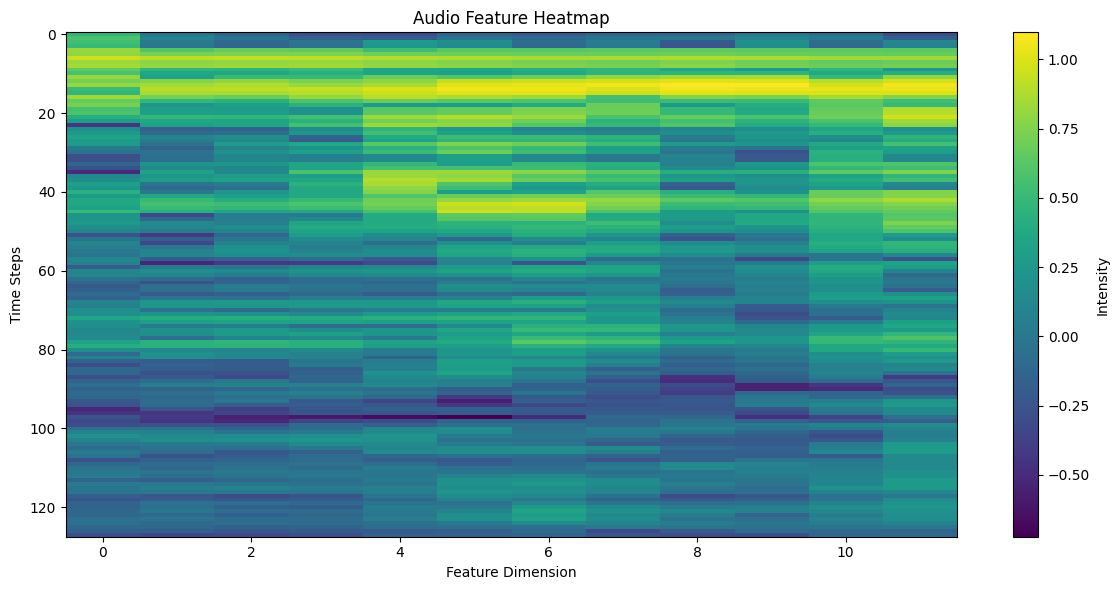

In [163]:
fe = WhisperFeatureExtractor.from_pretrained(
	"./models/whisper-large-v3-turbo",
	chunk_length=1,
	# feature_size=80
)

_x = fe(
	audio,
	padding="do_not_pad"
).input_features

print(_x.shape)

_mel_spectrogram = _x[0]
plt.figure(figsize=(12, 6))
plt.imshow(_mel_spectrogram, aspect='auto', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Feature Dimension')
plt.ylabel('Time Steps')
plt.title('Audio Feature Heatmap')
plt.tight_layout()
plt.show()

In [217]:
sample_rate = 16000
frame_duration = 10  # ms
frame = b'\x00\x00' * int(sample_rate * frame_duration / 1000)
print(len(frame))
# print(f'Contains speech: {vad.is_speech(frame, sample_rate)}')

320


In [298]:
# frame_samples

1 * (sr * sw * ch)


32000